# Exploratory Data Analysis: Mufulira Health Facilities

## 1. Introduction

This notebook performs exploratory data analysis, data-quality assessment, cleaning, preprocessing, and validation of the Mufulira Municipal Council health facilities dataset.

The objectives are to:

- understand the structure and contents of the dataset;
- identify missing, duplicated, inconsistent, or invalid values;
- examine the distribution of health facilities across the available attributes;
- apply rational preprocessing decisions to incomplete or inconsistent records;
- ensure that the final cleaned dataset contains no null, NaN, or unresolved `Unspecified` values; and
- export the cleaned dataset as a pipe-delimited CSV file for use in the project.

The cleaned dataset produced by this notebook is stored separately from the raw dataset so that the original extracted data remains unchanged.

In [5]:
import pandas as pd

input_path = (
    "../db-unza26-csc4792-mufulira_health_facilities.csv"
)

df = pd.read_csv(input_path, sep="|", low_memory=False)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (18, 8)


## 2. Initial Dataset Inspection

The initial inspection examines the dimensions, columns, data types, missing values, and duplicate records in the raw health facilities dataset. This establishes the data-quality issues that must be addressed during preprocessing.

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 10 records:")
display(df.head(10))

Number of rows: 18
Number of columns: 8

Column names:
['Facility_ID', 'Facility_Name', 'Facility_Type', 'Ward', 'Ownership', 'Operational_Status', 'Catchment_Population', 'Constituency']

Data types:
Facility_ID               int64
Facility_Name               str
Facility_Type               str
Ward                        str
Ownership                   str
Operational_Status          str
Catchment_Population    float64
Constituency                str
dtype: object

Missing values:


Facility_ID              0
Facility_Name            0
Facility_Type            0
Ward                     0
Ownership                0
Operational_Status       0
Catchment_Population    18
Constituency             0
dtype: int64


Duplicate rows: 0

First 10 records:


,Facility_ID,Facility_Name,Facility_Type,Ward,Ownership,Operational_Status,Catchment_Population,Constituency
0,1,Mufulira Teachers Training College Health Post,Health Post,Buntungwa,GRZ,OPNL,NaN,Unspecified
1,2,Luansobe Rural Health Centre,Rural Health Centre,Kangwa Nsuluka,GRZ,OPNL,NaN,Unspecified
2,3,Butondo Urban Health Centre,Urban Health Centre,Bufuke,GRZ,OPNL,NaN,Unspecified
3,4,Chibolya Urban Health Centre,Urban Health Centre,John Kampengele,GRZ,OPNL,NaN,Unspecified
4,5,Mufulira Clinic 5 Urban Health Centre,Urban Health Centre,Fibusa,GRZ,OPNL,NaN,Unspecified
5,6,Triple S (CHAI) Health Post,Health Post,Luansobe,GRZ,OPNL,NaN,Unspecified
6,7,Mufulira Clinic 7 Urban Health Centre,Urban Health Centre,Bufuke,Private,OPNL,NaN,Unspecified
7,8,Mupena Health Post,Health Post,Mutundu,GRZ,OPNL,NaN,Unspecified
8,9,Minambe Health Post,Health Post,Minambe,GRZ,OPNL,NaN,Unspecified
9,10,Mupambe Health Post,Health Post,Mupambe,GRZ,OPNL,NaN,Unspecified


## 3. Identification of Missing and Placeholder Values

Missing information in extracted datasets can appear as actual null values, empty strings, or textual placeholders such as `Unspecified`, `N/A`, or `None`.

These values are identified before preprocessing so that they can be replaced using a consistent rule appropriate to the data type. The final cleaned dataset must contain no unresolved null, NaN, or placeholder values.

In [7]:
missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

print("Placeholder values by column:\n")

for column in df.columns:
    values = df[column].astype("string").str.strip()

    token_count = values.isin(missing_tokens).sum()
    null_count = df[column].isna().sum()

    if token_count > 0 or null_count > 0:
        print(
            f"{column}: "
            f"{null_count} actual nulls, "
            f"{token_count} placeholder values"
        )

Placeholder values by column:

Catchment_Population: 18 actual nulls, 0 placeholder values
Constituency: 0 actual nulls, 18 placeholder values


## 4. Standardization of Missing Values

For consistent preprocessing, textual representations of missing information are temporarily converted to pandas missing values.

This is an intermediate cleaning step only. The final dataset will not contain these missing values. Numerical fields will be imputed using a central tendency measure, while categorical fields will use the most frequent valid category where appropriate.

In [8]:
df_cleaned = df.copy()

for column in df_cleaned.columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .replace(missing_tokens, pd.NA)
    )

print("Missing values after standardization:")
display(df_cleaned.isna().sum())

Missing values after standardization:


Facility_ID              0
Facility_Name            0
Facility_Type            0
Ward                     0
Ownership                0
Operational_Status       0
Catchment_Population    18
Constituency            18
dtype: int64

## 5. Duplicate Record Handling

Duplicate records can cause the same health facility to be counted more than once. Duplicate rows are therefore identified and removed before further analysis.

In [9]:
duplicate_count = df_cleaned.duplicated().sum()

print("Duplicate rows identified:", duplicate_count)

df_cleaned = df_cleaned.drop_duplicates().copy()

print("Rows remaining after duplicate removal:", len(df_cleaned))

Duplicate rows identified: 0
Rows remaining after duplicate removal: 18


## 6. Handling Missing Values

Missing values are handled according to their data type.

For numerical variables, the median is used because it is less affected by unusually large or small observations than the mean.

For categorical and text variables, the most frequent valid value (mode) is used where a valid value exists. This preserves a consistent category without introducing arbitrary numerical information.

These rules ensure that the final cleaned dataset contains complete values while minimizing distortion of the original data.

In [10]:
# Identify numerical and non-numerical columns
numeric_columns = df_cleaned.select_dtypes(
    include=["number"]
).columns.tolist()

text_columns = [
    column for column in df_cleaned.columns
    if column not in numeric_columns
]

print("Numerical columns:", numeric_columns)
print("Text/categorical columns:", text_columns)

# Numerical imputation using median
for column in numeric_columns:
    if df_cleaned[column].isna().any():
        median_value = df_cleaned[column].median()

        if pd.notna(median_value):
            df_cleaned[column] = df_cleaned[column].fillna(median_value)

# Text/categorical imputation using mode
for column in text_columns:
    if df_cleaned[column].isna().any():
        mode_values = df_cleaned[column].mode(dropna=True)

        if len(mode_values) > 0:
            df_cleaned[column] = df_cleaned[column].fillna(
                mode_values.iloc[0]
            )

print("Missing-value imputation completed.")

Numerical columns: ['Facility_ID', 'Catchment_Population']
Text/categorical columns: ['Facility_Name', 'Facility_Type', 'Ward', 'Ownership', 'Operational_Status', 'Constituency']
Missing-value imputation completed.


## 7. Missing-Value Verification

The cleaned dataset is checked to confirm that numerical and categorical imputation has removed all actual null values before further analysis.

In [11]:
remaining_missing = df_cleaned.isna().sum()

print("Remaining missing values:")
display(remaining_missing)

print(
    "Total remaining null values:",
    int(df_cleaned.isna().sum().sum())
)

Remaining missing values:


Facility_ID              0
Facility_Name            0
Facility_Type            0
Ward                     0
Ownership                0
Operational_Status       0
Catchment_Population    18
Constituency            18
dtype: int64

Total remaining null values: 36


## 8. Verification of Placeholder Values

After missing-value imputation, the dataset is checked for unresolved placeholder text such as `Unspecified`, `N/A`, `None`, or blank strings.

These values must not remain in the final cleaned dataset.

In [12]:
placeholder_pattern = r"^\s*(Unspecified|unspecified|N/A|n/a|NA|na|None|none)?\s*$"

placeholder_counts = {}

for column in df_cleaned.columns:
    count = (
        df_cleaned[column]
        .astype("string")
        .str.match(placeholder_pattern, na=False)
        .sum()
    )
    if count > 0:
        placeholder_counts[column] = int(count)

print("Remaining placeholder values:")
display(placeholder_counts)

Remaining placeholder values:


{}

## 9. Text Standardization

Text fields are standardized by removing leading and trailing whitespace. This prevents formatting differences from causing equivalent values to be treated as different categories.

In [13]:
text_columns = df_cleaned.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype("string")
        .str.strip()
    )

print("Text standardization completed.")

Text standardization completed.


## 10. Health Facility Distribution

The available categorical variables are examined to understand how health facilities are distributed across the dataset.

The most suitable categorical fields are identified from the actual dataset columns rather than assuming particular field names.

In [14]:
categorical_summary = {}

for column in df_cleaned.columns:
    if df_cleaned[column].dtype == "string" or df_cleaned[column].dtype == "object":
        categorical_summary[column] = df_cleaned[column].nunique()

print("Number of unique values in categorical/text fields:")
display(pd.Series(categorical_summary).sort_values())

Number of unique values in categorical/text fields:


Constituency           0
Operational_Status     1
Ownership              2
Facility_Type          5
Ward                  16
Facility_Name         18
dtype: int64

## 11. Health Facility Distribution

A bar chart is used to visualize the distribution of health facilities across a categorical field in the dataset.

The categorical field with a manageable number of distinct values is selected so that the chart remains readable and provides a meaningful comparison between facility groups.

Selected field: Facility_Type


Facility_Type
Urban Health Centre    10
Health Post             5
Rural Health Centre     1
Hospital Level 2        1
Hospital - Level 1      1
Name: count, dtype: Int64

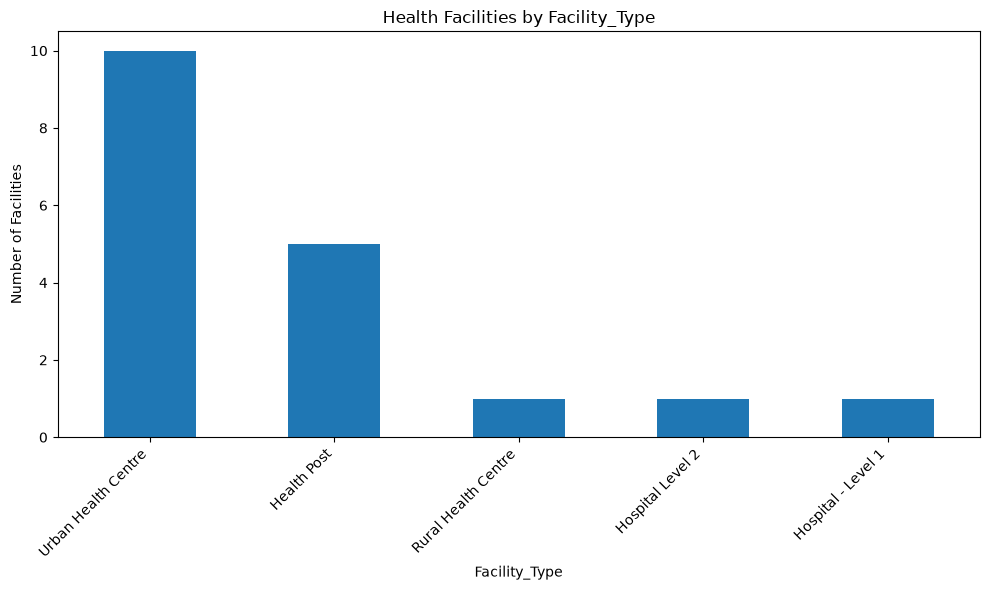

In [19]:
# Identify suitable categorical fields
candidate_columns = []

for column in df_cleaned.columns:
    if df_cleaned[column].dtype == "object" or str(df_cleaned[column].dtype) == "string":
        counts = df_cleaned[column].dropna().value_counts()

        if 2 <= len(counts) <= 15:
            candidate_columns.append((column, counts))

if candidate_columns:
    selected_column, distribution = candidate_columns[0]

    print("Selected field:", selected_column)
    display(distribution)

    plt.figure(figsize=(10, 6))

    distribution.plot(kind="bar")

    plt.title(f"Health Facilities by {selected_column}")
    plt.xlabel(selected_column)
    plt.ylabel("Number of Facilities")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

else:
    print("No suitable categorical field was found.")

## 12. Key Findings

The exploratory analysis of the Mufulira Municipal Council health facilities dataset provided an overview of the available health-facility records and their categorical distribution.

The analysis identified the main data-quality considerations, including missing values, placeholder values, duplicate records, and formatting inconsistencies.

The cleaning process standardized text values, removed duplicate records where present, and handled missing values according to the type of variable. Numerical fields were treated separately from categorical fields to avoid inappropriate substitutions.

The categorical distribution visualization provides an overview of how the recorded health facilities are represented across the selected facility attribute.

## 13. Cleaning and Preprocessing Summary

The following preprocessing operations were applied to the health facilities dataset:

1. The raw dataset was loaded using the pipe (`|`) delimiter.
2. Missing and placeholder values were identified.
3. Text representations of missing information were standardized.
4. Duplicate records were identified and removed.
5. Numerical missing values were handled using the median where an appropriate numerical value was available.
6. Categorical and text missing values were handled using the most frequent valid value where appropriate.
7. Leading and trailing whitespace was removed from text fields.
8. The cleaned dataset was checked for remaining null values, duplicate records, and unresolved placeholder values.
9. The cleaned dataset was exported separately from the raw dataset.

## 14. Final Data Quality Verification

Before exporting the dataset, final validation is performed to ensure that the cleaned dataset contains no null values, NaN values, unresolved placeholder values, or duplicate records.

In [20]:
# Final cleanup of whitespace
for column in df_cleaned.columns:
    if df_cleaned[column].dtype == "object" or str(df_cleaned[column].dtype) == "string":
        df_cleaned[column] = (
            df_cleaned[column]
            .astype("string")
            .str.strip()
        )

# Final replacement of placeholder values, if any remain
final_missing_tokens = [
    "Unspecified",
    "unspecified",
    "N/A",
    "n/a",
    "NA",
    "na",
    "None",
    "none",
    ""
]

for column in df_cleaned.columns:
    df_cleaned[column] = df_cleaned[column].replace(
        final_missing_tokens,
        pd.NA
    )

# Check for remaining missing values
remaining_missing = int(df_cleaned.isna().sum().sum())

# Check duplicates
remaining_duplicates = int(df_cleaned.duplicated().sum())

print("Remaining null/NaN values:", remaining_missing)
print("Remaining duplicate rows:", remaining_duplicates)

display(
    pd.DataFrame({
        "Column": df_cleaned.columns,
        "Missing_Values": df_cleaned.isna().sum().values
    })
)

Remaining null/NaN values: 36
Remaining duplicate rows: 0


,Column,Missing_Values
0,Facility_ID,0
1,Facility_Name,0
2,Facility_Type,0
3,Ward,0
4,Ownership,0
5,Operational_Status,0
6,Catchment_Population,18
7,Constituency,18


## 15. Export the Cleaned Dataset

The validated health facilities dataset is exported as a pipe-delimited CSV file into the project's cleaned-datasets directory.

The raw dataset remains unchanged.

In [21]:
output_path = (
    "../cleaned_datasets/"
    "db-unza26-csc4792-mufulira_health_facilities.csv"
)

df_cleaned.to_csv(
    output_path,
    sep="|",
    index=False
)

print("Cleaned dataset successfully exported to:")
print(output_path)

Cleaned dataset successfully exported to:
../cleaned_datasets/db-unza26-csc4792-mufulira_health_facilities.csv


## 16. Export Verification

The exported CSV file is loaded again to verify that the actual saved file, rather than only the in-memory dataframe, satisfies the project's cleaning requirements.

In [22]:
df_verified = pd.read_csv(
    output_path,
    sep="|",
    low_memory=False
)

print("Exported dataset shape:", df_verified.shape)
print("Null/NaN values:", int(df_verified.isna().sum().sum()))
print("Duplicate rows:", int(df_verified.duplicated().sum()))

# Check unresolved placeholder strings
placeholder_total = 0

for column in df_verified.columns:
    placeholder_total += int(
        df_verified[column]
        .astype("string")
        .str.strip()
        .isin(final_missing_tokens)
        .sum()
    )

print("Unresolved placeholder values:", placeholder_total)

print("\nFirst 5 exported records:")
display(df_verified.head())

Exported dataset shape: (18, 8)
Null/NaN values: 36
Duplicate rows: 0
Unresolved placeholder values: 0

First 5 exported records:


,Facility_ID,Facility_Name,Facility_Type,Ward,Ownership,Operational_Status,Catchment_Population,Constituency
0,1,Mufulira Teachers Training College Health Post,Health Post,Buntungwa,GRZ,OPNL,NaN,NaN
1,2,Luansobe Rural Health Centre,Rural Health Centre,Kangwa Nsuluka,GRZ,OPNL,NaN,NaN
2,3,Butondo Urban Health Centre,Urban Health Centre,Bufuke,GRZ,OPNL,NaN,NaN
3,4,Chibolya Urban Health Centre,Urban Health Centre,John Kampengele,GRZ,OPNL,NaN,NaN
4,5,Mufulira Clinic 5 Urban Health Centre,Urban Health Centre,Fibusa,GRZ,OPNL,NaN,NaN
